In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
from synth_utils import run_synth_random, SynthDataConfig
from gap_est_utils import MethodConfig
from plot_utils import get_error_stats, plot_error_by_udim, plot_error_decomp
import warnings
warnings.filterwarnings("ignore", message="X has feature names")
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in")
warnings.simplefilter(action='ignore', category=FutureWarning)


### Run synthetic experiments

In [36]:
# Synthetic data generation config
data_config = SynthDataConfig(
    n=10000,
    clf="xgb", # fp model type
    n_tasks=5,
    n_seeds=10,
    U_schema={"normal": 0, "uniform": 0, "bernoulli": 4, "corr_U": 0.15},
    X_schema={"binary": 7, "cont": 0}, # Xtilde + XU, as descr. in Appendix; fn of U
    C_schema={"binary": 6, "cont": 0}, # XC; either independent or a collider
    dXtilde=5,
)

In [37]:
# Config for bound estimation method
method_config = MethodConfig(
    heuristic_bootstrap=700,
    heuristic_alpha=0.0005,
    heuristic_type='fast',
    clf=data_config.clf,
    standardize_P=True
)

In [8]:
### Run experiments 
# In run_synth_random, we iterate over n_tasks where each task is 
# identified by search for sizeable generalization gap,
# and then iterate over n_seeds. Each task x seed  calls on 
#
#     gapest = Generalization_Bound_Estimator(simulate_mode=True)
#     df = gapest.run(Xtilde_cols=Xtilde_cols, Y_col='Y', U_cols=U_cols, seed=seed, 
#                 pred_model=synth_config.get_model(seed=seed), 
#                 baselines=baselines, Q_df=Q_df, Q_mu=Q_mu, 
#                 Q_var=Q_var)
# 

#  which iteratres over all Utilde subsets of U internally (because simulate_mode=True).
# gapest.run will collect RQhat on the following methods / baselines : 
#     - trueUstar : our bound RQhat if the true U* were identified 
#     - predUstar : our bound RQhat using our heuristic moment matching algorithm
#     - naive IPPW of Utilde: propensity weighting using the identified Utilde selection variables
#     - calibration: empirical calibraiton using first moments 
#     - eb: entroyp balancing using first and second moments 
#     - raking: matches table counts of only discrete variables 
# and return the results in a dataframe. 

results = run_synth_random(data_config, method_config)

Processing tasks:   0%|          | 0/5 [00:00<?, ?it/s]

### Plot results 

In [12]:
# 1. Basic error RQhat - RQ stats for all methods
get_error_stats(results)

,method,mean_error,std_error,perc_valid_bound,5perc,95perc,design effect
0,Raking,-0.054865,0.025442,0.000000,-0.08,-0.03,1.0
0,Calibration,-0.003652,0.034937,0.800000,-0.04,0.04,4.3
0,Ent. balancing,-0.003936,0.034326,0.800000,-0.04,0.04,4.2
0,Naive IPPW of $\tilde{U}$,-0.019681,0.039293,0.360000,-0.07,0.03,2.9
0,UB (true $U^*$),0.063854,0.070362,0.906667,-0.02,0.20,6.5
0,UB (heuristic $U^*$),0.059384,0.054683,0.946667,-0.01,0.17,5.9


Setting max_udim to  4


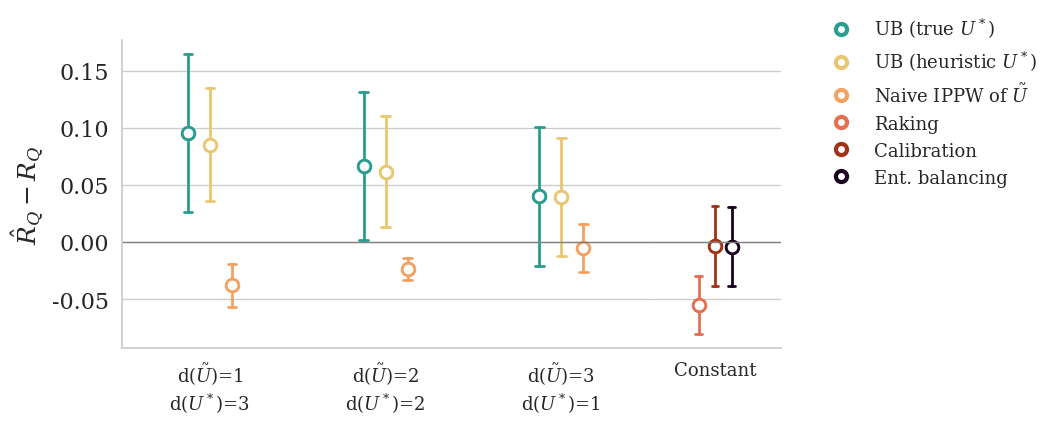

In [13]:
# 2. Error based on dim(Utilde) observed 
plot_error_by_udim(results)

In [ ]:
# 3. RQhat - RQ bound decomposition into assumption violations 
plot_error_decomp(results,'task',figsize=(8,4))
plot_error_decomp(results)

### See decomp.png for the plot -- running the above displayed author identifying information 


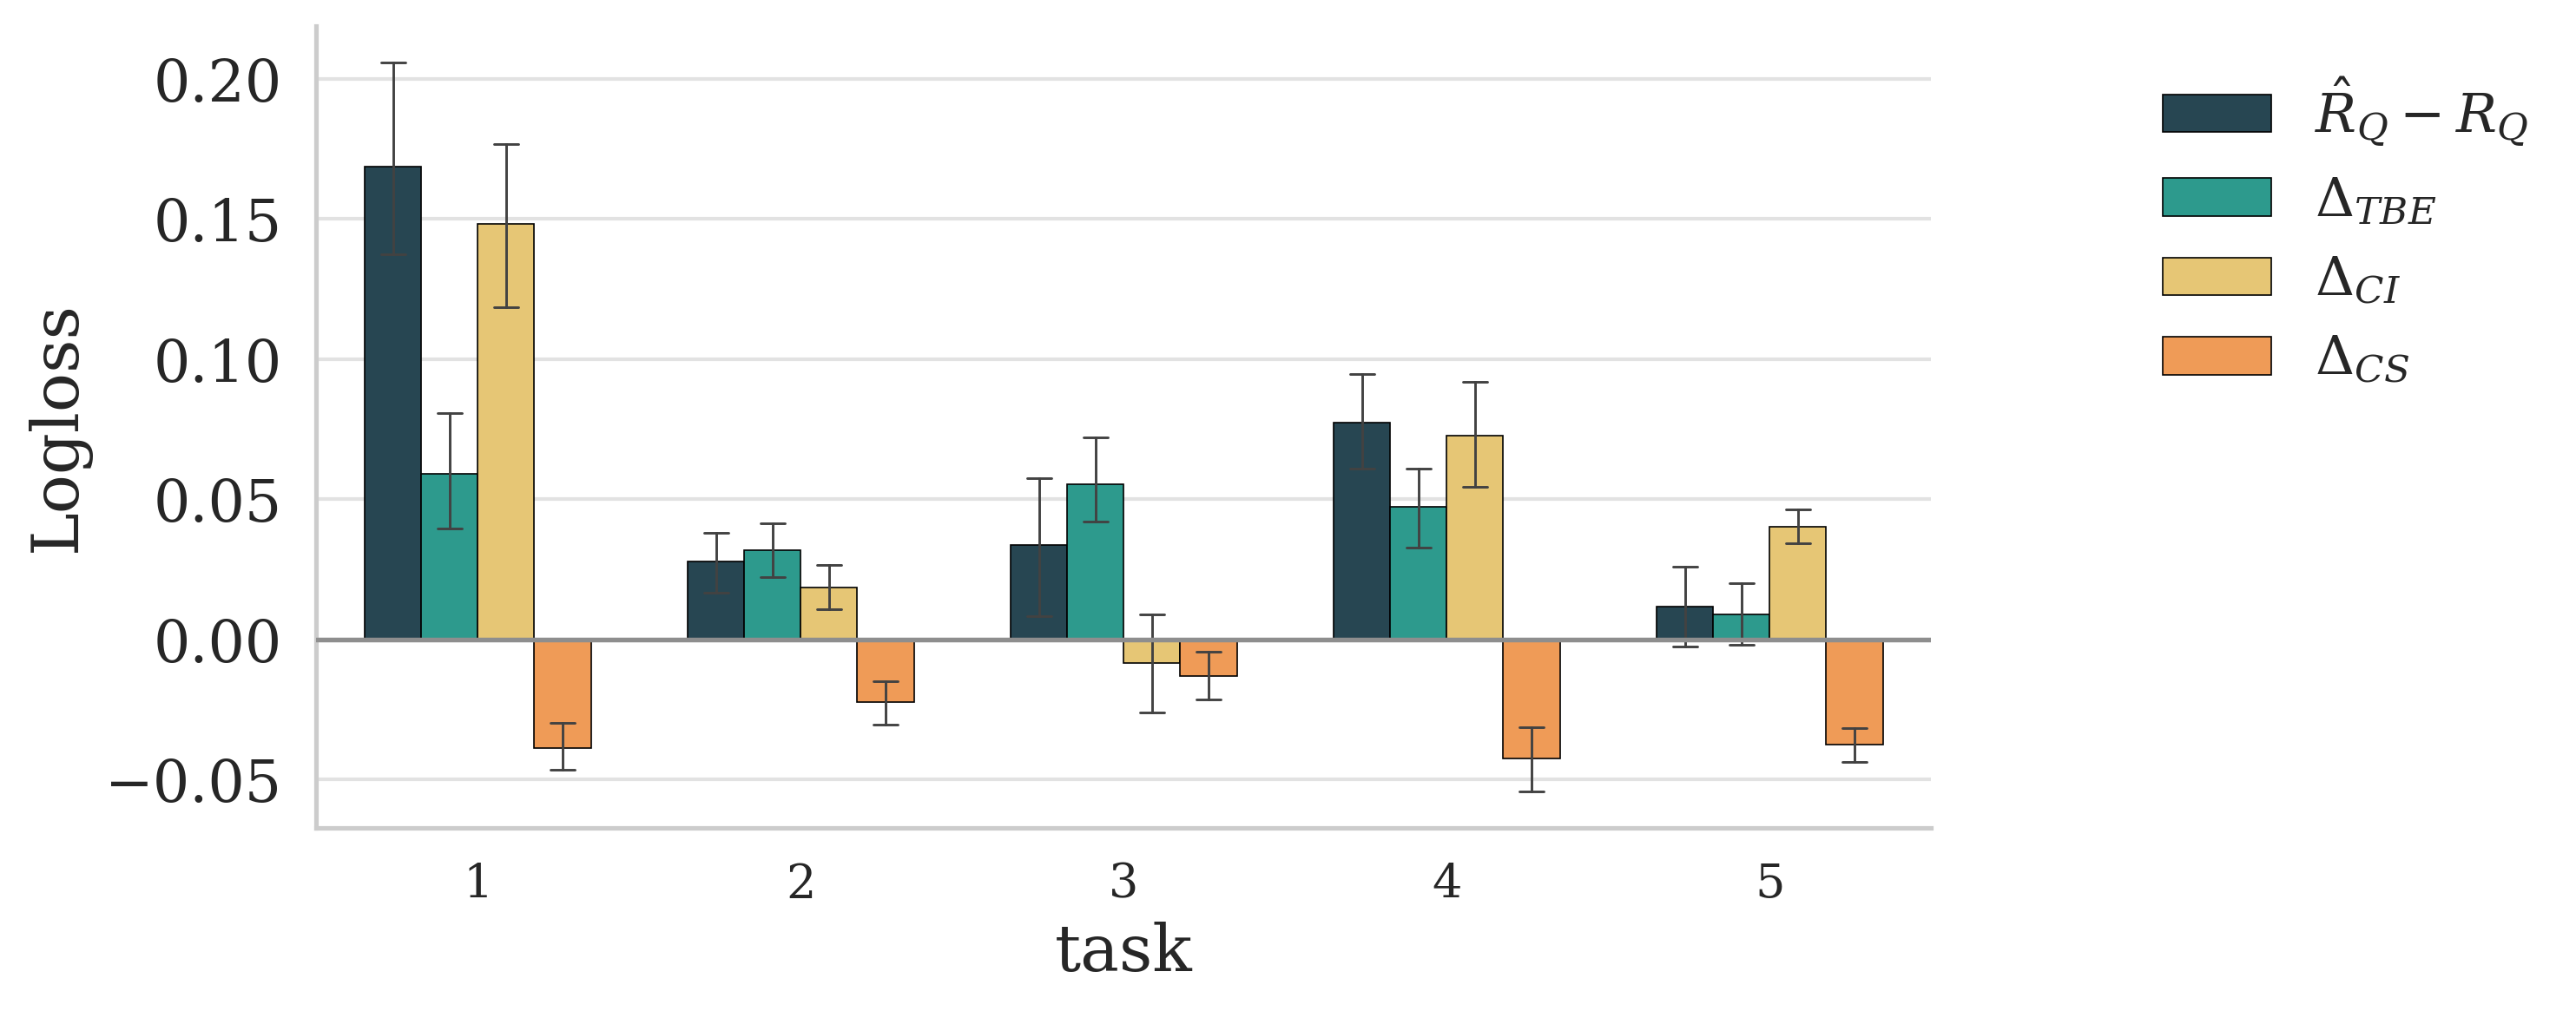

In [22]:
from IPython.display import Image
Image(filename='decomp_example.png') 

In [16]:
# 4. Diagnostic heuristics, per task (avgd over seeds)

results.groupby(['task', 'Utilde_cols'])[['Utilde_propensity_ks_stat', 'Utilde_propensity_ks_pval',
       'heuristic_w_de', 'propinv_ci_avg_var']].mean().rename(columns={'Utilde_propensity_ks_stat': "KS Propsensity (stat)", 'Utilde_propensity_ks_pval': "KS Propensity (pval)", 
 "heuristic_w_de": "Weight design effect", "propinv_ci_avg_var": "Prop. Inv. Var."})



KS Propsensity (stat)  KS Propensity (pval)  \
task Utilde_cols                                                             
1    ['U0', 'U1', 'U2', 'U3']               0.402172         1.567667e-139   
     ['U0', 'U1', 'U2']                     0.234192          1.483140e-59   
     ['U0', 'U1', 'U3']                     0.396417         1.567667e-139   
     ['U0', 'U1']                           0.223991          1.054509e-39   
     ['U0', 'U2', 'U3']                     0.385975          5.830355e-97   
...                                              ...                   ...   
5    ['U1', 'U3']                           0.212192          4.986418e-21   
     ['U1']                                 0.051283          4.050335e-02   
     ['U2', 'U3']                           0.318240          2.614808e-92   
     ['U2']                                 0.261067          4.280401e-45   
     ['U3']                                 0.196118          2.305368e-04   

                               Weight design effect  Prop. Inv. Var.  
task Utilde_cols                                                      
1    ['U0', 'U1', 'U2', 'U3']             40.234170         0.021156  
     ['U0', 'U1', 'U2']                   40.234170         0.021867  
     ['U0', 'U1', 'U3']                   40.234170         0.009459  
     ['U0', 'U1']                         40.234170         0.008300  
     ['U0', 'U2', 'U3']                   40.234170         0.017592  
...                                             ...              ...  
5    ['U1', 'U3']                          4.267647         0.014921  
     ['U1']                                4.267647         0.005513  
     ['U2', 'U3']                          4.267647         0.018544  
     ['U2']                                4.267647         0.008565  
     ['U3']                                4.267647         0.015790  

[75 rows x 4 columns]